# 04: Walk-Forward ML Ranking

**Thin client** over `src/models`. Runs the expanding-window walk-forward for the
baseline (ElasticNet) and tree (LightGBM) models, compares out-of-sample IC, and
runs the **leakage test** (shuffled target → IC ≈ 0).

> Quick ~30-ticker sample: magnitudes are noise; we validate that the harness is
> leak-free and that combining signals is wired correctly.

In [1]:
import sys; sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import cache
from src.factors import evaluate
from src.factors.panel import _feature_list
from src.models import rankers, walkforward

plt.style.use('seaborn-v0_8-whitegrid')
panel = cache.load('panel.parquet')
features = _feature_list()
print('panel:', panel.shape, '| features:', len(features))

panel: (9480, 22) | features: 16


In [2]:
# Walk-forward OOS predictions for each model
results = {}
for name in ['elasticnet', 'lightgbm']:
    preds = walkforward.walk_forward_predict(panel, rankers.get_model_factory(name), features)
    ic = evaluate.information_coefficient(preds, 'pred', target='forward_return')
    results[name] = (preds, ic, evaluate.ic_summary(ic))

summary = pd.DataFrame({k: v[2] for k, v in results.items()}).T
summary.round(4)

,ic_mean,ic_std,ic_ir,t_stat,hit_rate,n_months
elasticnet,0.0098,0.2372,0.0413,0.5669,0.5266,188.0
lightgbm,0.0017,0.2253,0.0075,0.0960,0.4847,163.0


## Leakage test — shuffled target must give IC ≈ 0

In [3]:
np.random.seed(42)
shuffled = panel.copy()
shuffled['target'] = shuffled.groupby('date')['target'].transform(lambda s: s.sample(frac=1).values)
preds_sh = walkforward.walk_forward_predict(shuffled, rankers.get_model_factory('elasticnet'), features)
ic_sh = evaluate.information_coefficient(preds_sh, 'pred', target='forward_return')
sh = evaluate.ic_summary(ic_sh)
real = results['elasticnet'][2]
print(f"Real:     mean IC {real['ic_mean']:+.4f}, t-stat {real['t_stat']:+.2f}")
print(f"Shuffled: mean IC {sh['ic_mean']:+.4f}, t-stat {sh['t_stat']:+.2f}")
# Leakage check: with the target shuffled, predictive power must be statistically insignificant.
assert abs(sh['t_stat']) < 2.0, 'Leakage! shuffled signal is significant'
print('\nLeakage test PASSED: shuffled target yields no significant IC.')

Real:     mean IC +0.0098, t-stat +0.57
Shuffled: mean IC -0.0319, t-stat -1.92

Leakage test PASSED: shuffled target yields no significant IC.


## Cumulative IC over time

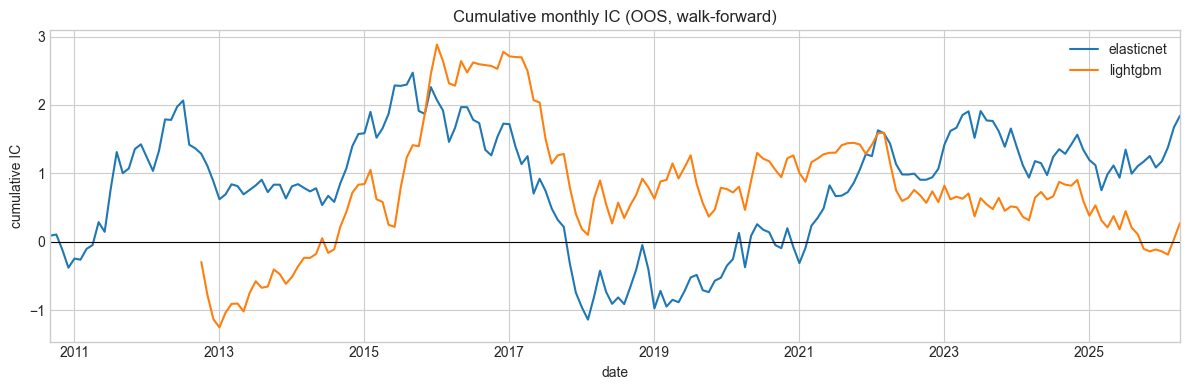

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
for name, (_, ic, _) in results.items():
    ic.sort_index().cumsum().plot(ax=ax, label=name)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Cumulative monthly IC (OOS, walk-forward)')
ax.set_ylabel('cumulative IC'); ax.legend()
plt.tight_layout(); plt.show()

## Notes

- On the full universe (drop `--quick`), LightGBM should beat the single-signal and
  ElasticNet baselines by capturing factor interactions.
- `min_child_samples` in `config/model.yaml` is tuned for the full universe; it starves
  the tree on the tiny quick sample (hence near-zero IC here).
- **Next**: `notebooks/05_backtest_report.ipynb` — long-only portfolio + cost-aware backtest.